In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Creating the main full ground truth grid 

In [2]:
# master ground-truth grid size 
SIZE = 20

In [3]:
grid_size = SIZE
x = np.arange(0, grid_size, 1)
y = np.arange(0, grid_size, 1)
X, Y = np.meshgrid(x, y)

center_x, center_y = grid_size / 2, grid_size / 2

u_saddle = X - center_x  # points iout along the x axis
v_saddle = center_y - Y  # Points in along the y axis

#normalisation 
epsilon = 1e-10
magnitude = np.sqrt(u_saddle**2 + v_saddle**2) + epsilon

u_normalized = u_saddle / magnitude
v_normalized = v_saddle / magnitude

# create the gt_grid array
gt_grid = np.stack((u_normalized, v_normalized), axis=-1)

# Downsampling every "N" th row for the Microscopy data 

In [4]:
# sampling interval
N = 2

In [5]:
# sample the Grid for Microscopy dat
microscopy_data = np.full(gt_grid.shape, np.nan)

# copy data for every Nth row from gt_grid to the microscopy_data grid
for i in range(0, grid_size, N):
    microscopy_data[i, :, :] = gt_grid[i, :, :]

# Visualisation of the full ground truth 

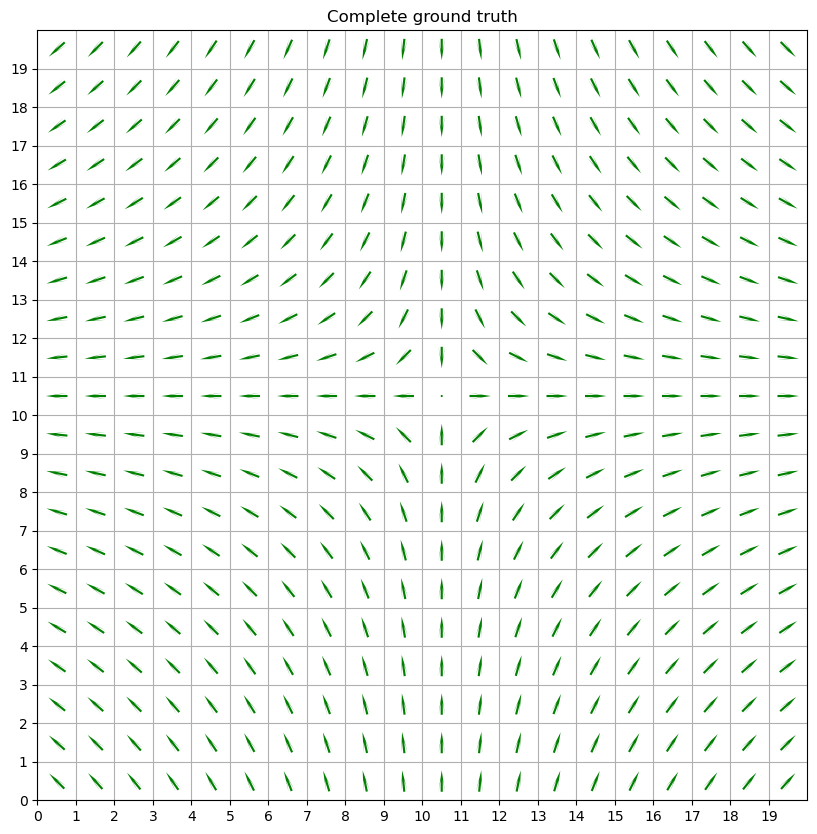

In [6]:
u_full = gt_grid[:, :, 0]
v_full = gt_grid[:, :, 1]

fig, ax = plt.subplots(figsize=(10, 10))

ax.quiver(X + 0.5, Y + 0.5, u_full, v_full, pivot='middle', headwidth=3, headlength=10, color='g')

ax.set_xticks(np.arange(0, grid_size , 1))
ax.set_yticks(np.arange(0, grid_size , 1))
# ax.set_xticklabels([])
# ax.set_yticklabels([])
ax.set_xlim([0, grid_size])
ax.set_ylim([0, grid_size])
ax.set_aspect('equal', adjustable='box')
plt.grid(True)
plt.title(f'Complete ground truth')
plt.show()

# Visualisation of the sampled "microscopy" data

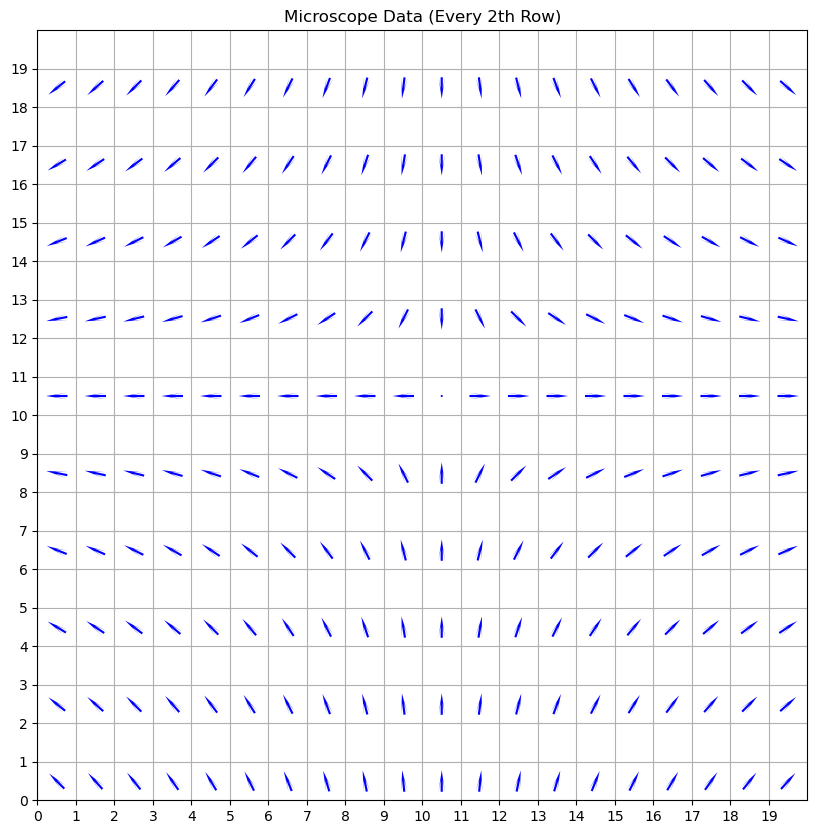

In [7]:

u_sampled = microscopy_data[:, :, 0]
v_sampled = microscopy_data[:, :, 1]

fig, ax = plt.subplots(figsize=(10, 10))

ax.quiver(X+0.5, Y+0.5, u_sampled, v_sampled, pivot='middle', headwidth=3, headlength=10,color='b')

ax.set_xticks(np.arange(0, grid_size, 1))
ax.set_yticks(np.arange(0, grid_size, 1))
# ax.set_xticklabels([])
# ax.set_yticklabels([])
ax.set_xlim([0, grid_size])
ax.set_ylim([0, grid_size])
ax.set_aspect('equal', adjustable='box')
plt.grid(True)
plt.title(f'Microscope Data (Every {N}th Row)')

plt.show()

# Generating the "DWI" data (resultant of each sampled patch of PxP size)

In [8]:
P = 4

In [9]:
# grid (np.array): The input vector field 
# patch_size (int): The width and height of each patch (e.g., 4)
grid = gt_grid
patch_size = P

grid_h, grid_w, _ = grid.shape

# dim of the dwi grid
new_h = int(np.ceil(grid_h / patch_size))
new_w = int(np.ceil(grid_w / patch_size))

resultant_grid = np.zeros((new_h, new_w, 2)) # empty array to store the new resultant vectors

epsilon = 1e-10

# Iterate over the new, smaller grid
for i in range(new_h):
    for j in range(new_w):
        
        # --- 1. Define and get the patch ---
        # Find the boundaries of the patch in the original grid
        y_start = i * patch_size
        y_end = y_start + patch_size
        x_start = j * patch_size
        x_end = x_start + patch_size
        
        # Slice the original grid to get the patch
        # patch.shape will be (patch_size, patch_size, 2)
        patch = grid[y_start:y_end, x_start:x_end]
        
        # --- 2. Calculate the resultant vector ---
        # We sum all vectors in the patch.
        # axis=(0, 1) sums over the patch's y and x dimensions.
        # This leaves just the 2-element vector (u_sum, v_sum).
        resultant_vector = np.sum(patch, axis=(0, 1)) # Shape (2,)
        
        # --- 3. Normalize the resultant vector ---
        magnitude = np.linalg.norm(resultant_vector) + epsilon
        normalized_vector = resultant_vector / magnitude
        
        # Store it in our new grid
        resultant_grid[i, j] = normalized_vector
        

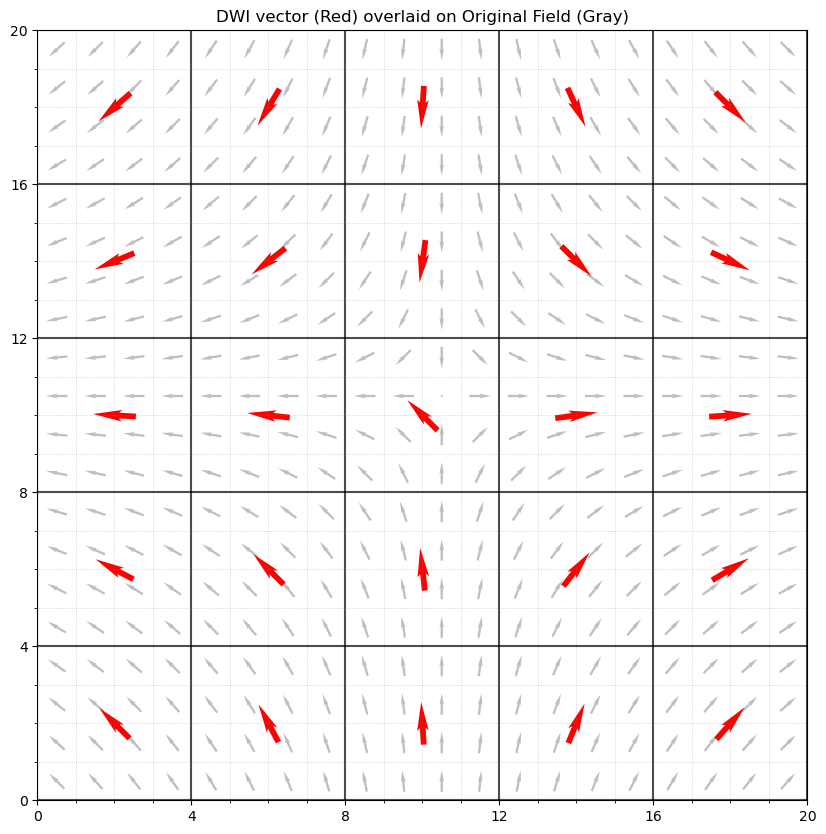

In [10]:
# Unpack the original "ground_truth" field
u_fine = gt_grid[:, :, 0]
v_fine = gt_grid[:, :, 1]

# Unpack the new "coarse" field
u_coarse = resultant_grid[:, :, 0]
v_coarse = resultant_grid[:, :, 1]

coarse_x = np.arange(patch_size / 2 , grid_size, patch_size)
coarse_y = np.arange(patch_size / 2 , grid_size, patch_size)
X_coarse, Y_coarse = np.meshgrid(coarse_x, coarse_y)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title(f'DWI vector (Red) overlaid on Original Field (Gray)')

# 1. Plot the original field in light gray
ax.quiver(X+0.5, Y+0.5, u_fine, v_fine, pivot='middle', 
          color='gray', alpha=0.5, headwidth=2, headlength=5) 

# 2. Plot the resultant field in bold red
ax.quiver(X_coarse, Y_coarse, u_coarse, v_coarse, pivot='middle', 
          color='red', headwidth=2, headlength=5) #  smaller scale makes arrows larger

# 1. Set Major ticks for the patch boundaries
major_ticks = np.arange(0, grid_size + 1, patch_size)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)

# 2. Set Minor ticks for the fine pixel grid
minor_ticks = np.arange(0, grid_size + 1, 1)
ax.set_xticks(minor_ticks, minor=True)
ax.set_yticks(minor_ticks, minor=True)

# 3. Set the plot limits
ax.set_xlim([0, grid_size])
ax.set_ylim([0, grid_size])

# 4. Draw the grids
# Draw the Major grid (thick, black) for the patches
ax.grid(which='major', color='black', linestyle='-', linewidth=1.5, alpha=0.7)
# Draw the Minor grid (thin, gray) for the pixels
ax.grid(which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

# 5. Hide all tick labels
#ax.set_xticklabels([])ax.set_yticklabels([])
ax.set_aspect('equal', adjustable='box')

plt.show()